# Notebook 02 - Modelos Deep Learning

Entrena y compara MLP con Adam, MLP con SGD momentum, LSTM y GRU. El Mundial 2022 queda reservado como test.
Para que el dashboard siempre funcione con features tabulares, se exporta el mejor MLP como `dashboard_model.keras`.

In [1]:
from pathlib import Path  # Maneja rutas del proyecto.
import time  # Mide velocidad de modelos recurrentes.
import warnings  # Controla avisos.

import joblib  # Guarda scaler y metadatos.
import numpy as np  # Maneja matrices numericas.
import pandas as pd  # Carga datos procesados.
import matplotlib.pyplot as plt  # Grafica curvas y matriz.

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score  # Calcula metricas.
from sklearn.model_selection import train_test_split  # Divide entrenamiento y validacion.
from sklearn.preprocessing import StandardScaler  # Normaliza variables.

import tensorflow as tf  # Motor de deep learning.
from tensorflow import keras  # API Keras.
from tensorflow.keras import layers, regularizers  # Capas y regularizacion.

warnings.filterwarnings("ignore")  # Limpia avisos menores.
np.random.seed(42)  # Fija semilla numpy.
tf.random.set_seed(42)  # Fija semilla TensorFlow.
plt.style.use("ggplot")  # Estilo grafico sin paquetes extra.

In [2]:
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()  # Detecta raiz.
DATA_DIR = ROOT / "artifacts" / "data"  # Datos procesados.
MODEL_DIR = ROOT / "artifacts" / "models"  # Modelos exportados.
MODEL_DIR.mkdir(parents=True, exist_ok=True)  # Crea carpeta de modelos.

df = pd.read_csv(DATA_DIR / "feature_dataset.csv", parse_dates=["date"])  # Carga dataset final.
feature_cols = pd.read_csv(DATA_DIR / "feature_columns.csv")["feature"].tolist()  # Carga columnas.
train_df = df[(df["is_world_cup_2022_test"] == 0) & (df["date"] < "2022-11-20")].copy()  # Entrena antes del test.
test_df = df[df["is_world_cup_2022_test"] == 1].copy()  # Reserva Mundial 2022.

X = train_df[feature_cols].astype(float).values  # Matriz de features.
y = train_df["target_result"].astype(int).values  # Etiquetas de resultado.
y_goals = train_df[["target_home_goals", "target_away_goals"]].astype(float).values  # Objetivo de marcador.
X_test = test_df[feature_cols].astype(float).values  # Features de test.
y_test = test_df["target_result"].astype(int).values  # Etiquetas de test.

X_train, X_val, y_train, y_val, goals_train, goals_val = train_test_split(X, y, y_goals, test_size=0.2, random_state=42, stratify=y)  # Crea validacion.
scaler = StandardScaler()  # Inicializa normalizador.
X_train_s = scaler.fit_transform(X_train)  # Ajusta con train.
X_val_s = scaler.transform(X_val)  # Transforma validacion.
X_test_s = scaler.transform(X_test)  # Transforma test.
print(X_train_s.shape, X_val_s.shape, X_test_s.shape)  # Verifica dimensiones.

(21593, 42) (5399, 42) (64, 42)


In [3]:
def build_mlp(optimizer_name):  # Construye red MLP.
    inputs = keras.Input(shape=(len(feature_cols),), name="features")  # Entrada tabular.
    x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(inputs)  # Capa oculta 1 con L2.
    x = layers.Dropout(0.30)(x)  # Dropout regularizador.
    x = layers.Dense(96, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)  # Capa oculta 2 con L2.
    x = layers.Dropout(0.25)(x)  # Dropout intermedio.
    x = layers.Dense(64, activation="relu")(x)  # Capa oculta 3.
    x = layers.Dropout(0.20)(x)  # Dropout adicional.
    x = layers.Dense(32, activation="relu")(x)  # Capa oculta 4.
    result = layers.Dense(3, activation="softmax", name="resultado")(x)  # Probabilidades A/empate/B.
    goals = layers.Dense(2, activation="relu", name="goles")(x)  # Marcador estimado.
    model = keras.Model(inputs, [result, goals], name=f"mlp_{optimizer_name}")  # Modelo multi-salida.
    optimizer = keras.optimizers.SGD(0.01, momentum=0.9) if optimizer_name == "sgd" else keras.optimizers.Adam(0.001)  # Selecciona optimizador.
    model.compile(optimizer=optimizer, loss={"resultado": "sparse_categorical_crossentropy", "goles": "mse"}, loss_weights={"resultado": 1.0, "goles": 0.20}, metrics={"resultado": ["accuracy"]})  # Compila modelo.
    return model  # Devuelve modelo.

callbacks = [keras.callbacks.EarlyStopping(monitor="val_resultado_accuracy", mode="max", patience=2, restore_best_weights=True)]  # Evita sobreentrenar.

In [4]:
EPOCHS_MLP = 5  # Epocas moderadas para que ejecute en CPU.
BATCH = 64  # Tamano de lote.
mlp_adam = build_mlp("adam")  # Crea MLP Adam.
hist_adam = mlp_adam.fit(X_train_s, {"resultado": y_train, "goles": goals_train}, validation_data=(X_val_s, {"resultado": y_val, "goles": goals_val}), epochs=EPOCHS_MLP, batch_size=BATCH, callbacks=callbacks, verbose=1)  # Entrena Adam.
mlp_sgd = build_mlp("sgd")  # Crea MLP SGD.
hist_sgd = mlp_sgd.fit(X_train_s, {"resultado": y_train, "goles": goals_train}, validation_data=(X_val_s, {"resultado": y_val, "goles": goals_val}), epochs=EPOCHS_MLP, batch_size=BATCH, callbacks=callbacks, verbose=1)  # Entrena SGD.

Epoch 1/5


  1/338 ━━━━━━━━━━━━━━━━━━━━ 10:45 2s/step - goles_loss: 5.3207 - loss: 2.3295 - resultado_accuracy: 0.3125 - resultado_loss: 1.2479

 26/338 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - goles_loss: 4.7967 - loss: 2.0901 - resultado_accuracy: 0.4062 - resultado_loss: 1.1133  

 52/338 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - goles_loss: 4.2021 - loss: 1.9325 - resultado_accuracy: 0.4467 - resultado_loss: 1.0746

 77/338 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - goles_loss: 3.9210 - loss: 1.8527 - resultado_accuracy: 0.4679 - resultado_loss: 1.0511

...

262/338 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - goles_loss: 2.0235 - loss: 1.3458 - resultado_accuracy: 0.5750 - resultado_loss: 0.9243

286/338 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - goles_loss: 2.0134 - loss: 1.3434 - resultado_accuracy: 0.5751 - resultado_loss: 0.9240

311/338 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - goles_loss: 2.0045 - loss: 1.3412 - resultado_accuracy: 0.5752 - resultado_loss: 0.9236

336/338 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - goles_loss: 1.9973 - loss: 1.3394 - resultado_accuracy: 0.5753 - resultado_loss: 0.9232

338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - goles_loss: 1.9108 - loss: 1.3171 - resultado_accuracy: 0.5762 - resultado_loss: 0.9183 - val_goles_loss: 1.8319 - val_loss: 1.2852 - val_resultado_accuracy: 0.5871 - val_resultado_loss: 0.9015


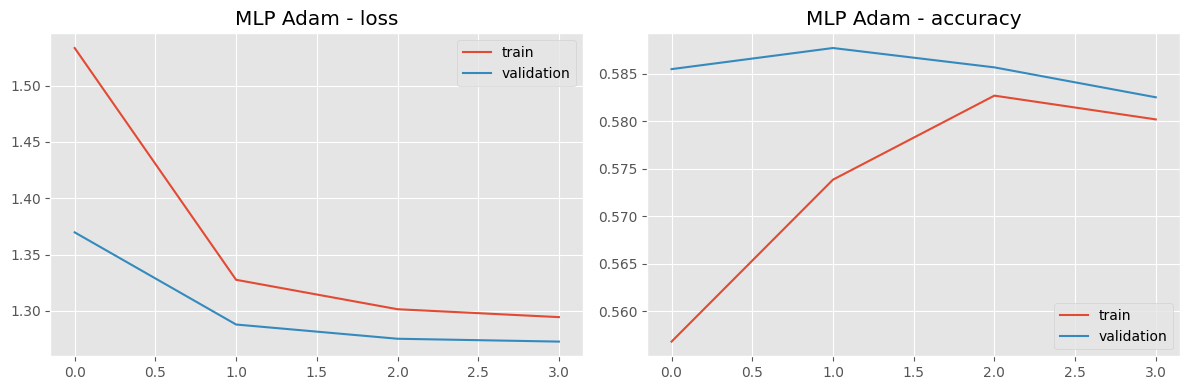

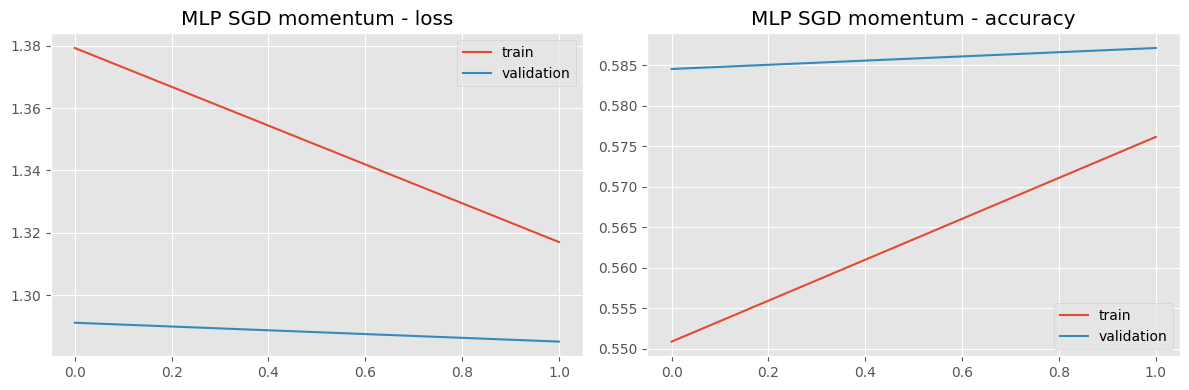

In [5]:
def plot_history(history, title):  # Grafica entrenamiento.
    hist = pd.DataFrame(history.history)  # Convierte historial a tabla.
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # Crea panel.
    axes[0].plot(hist["loss"], label="train")  # Loss train.
    axes[0].plot(hist["val_loss"], label="validation")  # Loss validacion.
    axes[0].set_title(f"{title} - loss")  # Titulo loss.
    axes[0].legend()  # Muestra leyenda.
    axes[1].plot(hist["resultado_accuracy"], label="train")  # Accuracy train.
    axes[1].plot(hist["val_resultado_accuracy"], label="validation")  # Accuracy validacion.
    axes[1].set_title(f"{title} - accuracy")  # Titulo accuracy.
    axes[1].legend()  # Muestra leyenda.
    plt.tight_layout()  # Ajusta espacios.
    plt.show()  # Muestra grafico.

plot_history(hist_adam, "MLP Adam")  # Grafica Adam.
plot_history(hist_sgd, "MLP SGD momentum")  # Grafica SGD.

## LSTM/GRU y vanishing gradient

La red recurrente recibe una ventana de los ultimos 10 partidos. En BPTT el gradiente contiene productos
repetidos de Jacobianos:

$$\frac{\partial L}{\partial h_t}=\sum_{k=t}^{T}\frac{\partial L}{\partial h_k}\prod_{j=t+1}^{k}\frac{\partial h_j}{\partial h_{j-1}}$$

Si la norma de muchos factores es menor que 1, el gradiente se reduce al retroceder en el tiempo. LSTM y GRU
usan compuertas para preservar informacion y reducir ese problema.

In [6]:
team_history = pd.read_csv(DATA_DIR / "team_match_history.csv", parse_dates=["date"])  # Carga historial largo.
sequence_cols = ["goals_for", "goals_against", "points", "goal_diff"]  # Variables temporales.
LOOKBACK = 10  # Ventana pedida por rubrica.
history_by_team = {team: part.sort_values("date") for team, part in team_history.groupby("team")}  # Indexa por equipo.

def recent_sequence(team, date):  # Obtiene ultimos partidos antes de la fecha.
    part = history_by_team.get(team)  # Busca historial del equipo.
    if part is None:  # Maneja equipo sin historial.
        return np.zeros((LOOKBACK, len(sequence_cols)))  # Devuelve ceros.
    values = part[part["date"] < date].tail(LOOKBACK)[sequence_cols].to_numpy(dtype=float)  # Extrae previos.
    padded = np.zeros((LOOKBACK, len(sequence_cols)))  # Crea matriz con padding.
    if len(values) > 0:  # Si existen previos.
        padded[-len(values):] = values  # Alinea al final.
    return padded  # Devuelve secuencia.

def sequence_for_row(row):  # Crea secuencia comparativa.
    home = recent_sequence(row["home_team"], row["date"])  # Secuencia equipo A.
    away = recent_sequence(row["away_team"], row["date"])  # Secuencia equipo B.
    return np.concatenate([home, away, home - away], axis=1)  # Une A, B y diferencia.

seq_train_source = train_df.tail(9000).reset_index(drop=True)  # Usa muestra reciente para ejecutar rapido.
seq_test_source = test_df.reset_index(drop=True)  # Usa todo el test 2022.
X_seq = np.stack([sequence_for_row(row) for _, row in seq_train_source.iterrows()])  # Construye tensor train.
y_seq = seq_train_source["target_result"].astype(int).values  # Etiquetas train.
X_seq_test = np.stack([sequence_for_row(row) for _, row in seq_test_source.iterrows()])  # Construye tensor test.
X_seq_train, X_seq_val, y_seq_train, y_seq_val = train_test_split(X_seq, y_seq, test_size=0.2, random_state=42, stratify=y_seq)  # Divide secuencias.
print(X_seq_train.shape, X_seq_val.shape, X_seq_test.shape)  # Verifica tensores.

(7200, 10, 12) (1800, 10, 12) (64, 10, 12)


In [7]:
def build_recurrent(kind):  # Construye LSTM o GRU.
    recurrent = layers.LSTM if kind == "lstm" else layers.GRU  # Selecciona tipo de capa.
    inputs = keras.Input(shape=(LOOKBACK, X_seq_train.shape[-1]), name="trayectoria")  # Entrada secuencial.
    x = recurrent(48, return_sequences=True, dropout=0.20)(inputs)  # Primera capa recurrente.
    x = recurrent(24, dropout=0.20)(x)  # Segunda capa recurrente.
    x = layers.Dense(24, activation="relu")(x)  # Capa densa final.
    outputs = layers.Dense(3, activation="softmax")(x)  # Probabilidades de clase.
    model = keras.Model(inputs, outputs, name=kind)  # Crea modelo.
    model.compile(optimizer=keras.optimizers.Adam(0.001), loss="sparse_categorical_crossentropy", metrics=["accuracy"])  # Compila.
    return model  # Devuelve modelo.

seq_callbacks = [keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=1, restore_best_weights=True, mode="max")]  # Detiene rapido.
start = time.time()  # Inicia tiempo LSTM.
lstm = build_recurrent("lstm")  # Crea LSTM.
hist_lstm = lstm.fit(X_seq_train, y_seq_train, validation_data=(X_seq_val, y_seq_val), epochs=3, batch_size=BATCH, callbacks=seq_callbacks, verbose=1)  # Entrena LSTM.
lstm_seconds = time.time() - start  # Guarda tiempo LSTM.
start = time.time()  # Inicia tiempo GRU.
gru = build_recurrent("gru")  # Crea GRU.
hist_gru = gru.fit(X_seq_train, y_seq_train, validation_data=(X_seq_val, y_seq_val), epochs=3, batch_size=BATCH, callbacks=seq_callbacks, verbose=1)  # Entrena GRU.
gru_seconds = time.time() - start  # Guarda tiempo GRU.

Epoch 1/3


  1/113 ━━━━━━━━━━━━━━━━━━━━ 5:42 3s/step - accuracy: 0.3125 - loss: 1.0982

  9/113 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2934 - loss: 1.1103 

 18/113 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3366 - loss: 1.1021

 27/113 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3697 - loss: 1.0934

...

 87/113 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5245 - loss: 0.9992

 94/113 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5250 - loss: 0.9984

101/113 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5254 - loss: 0.9977

108/113 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5259 - loss: 0.9969

113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5342 - loss: 0.9866 - val_accuracy: 0.5433 - val_loss: 0.9615


In [8]:
def eval_mlp(model, name):  # Evalua MLP.
    probs, goals = model.predict(X_test_s, verbose=0)  # Predice clases y goles.
    pred = probs.argmax(axis=1)  # Convierte a clase.
    return {"modelo": name, "accuracy": accuracy_score(y_test, pred), "f1_macro": f1_score(y_test, pred, average="macro"), "segundos": np.nan}  # Devuelve metricas.

def eval_seq(model, name, seconds):  # Evalua recurrente.
    probs = model.predict(X_seq_test, verbose=0)  # Predice clases.
    pred = probs.argmax(axis=1)  # Convierte a clase.
    return {"modelo": name, "accuracy": accuracy_score(y_test, pred), "f1_macro": f1_score(y_test, pred, average="macro"), "segundos": seconds}  # Devuelve metricas.

metrics = pd.DataFrame([
    eval_mlp(mlp_adam, "MLP Adam"),
    eval_mlp(mlp_sgd, "MLP SGD momentum"),
    eval_seq(lstm, "LSTM", lstm_seconds),
    eval_seq(gru, "GRU", gru_seconds),
]).sort_values("f1_macro", ascending=False)  # Compara modelos.
display(metrics)  # Muestra tabla.
metrics.to_csv(MODEL_DIR / "metrics.csv", index=False)  # Guarda metricas.

,modelo,accuracy,f1_macro,segundos
0,MLP Adam,0.531250,0.395940,NaN
1,MLP SGD momentum,0.531250,0.394379,NaN
2,LSTM,0.484375,0.339787,6.320318
3,GRU,0.468750,0.329915,5.927796


In [9]:
mlp_metrics = metrics[metrics["modelo"].str.contains("MLP")].sort_values("f1_macro", ascending=False)  # Filtra MLP.
dashboard_name = mlp_metrics.iloc[0]["modelo"]  # Elige mejor MLP para dashboard.
dashboard_model = mlp_adam if dashboard_name == "MLP Adam" else mlp_sgd  # Recupera modelo elegido.

mlp_adam.save(MODEL_DIR / "mlp_adam.keras")  # Guarda MLP Adam.
mlp_sgd.save(MODEL_DIR / "mlp_sgd.keras")  # Guarda MLP SGD.
lstm.save(MODEL_DIR / "lstm.keras")  # Guarda LSTM.
gru.save(MODEL_DIR / "gru.keras")  # Guarda GRU.
dashboard_model.save(MODEL_DIR / "dashboard_model.keras")  # Guarda modelo seguro para dashboard.
dashboard_model.save(MODEL_DIR / "best_model.keras")  # Guarda alias de modelo elegido.
joblib.dump({"scaler": scaler, "feature_cols": feature_cols, "dashboard_model": dashboard_name, "metrics": metrics.to_dict(orient="records")}, MODEL_DIR / "model_bundle.pkl")  # Guarda bundle.
print("Modelo usado en dashboard:", dashboard_name)  # Reporta decision.

Modelo usado en dashboard: MLP Adam


              precision    recall  f1-score   support

      Gana A       0.57      0.75      0.65        28
      Empate       0.00      0.00      0.00        15
      Gana B       0.48      0.62      0.54        21

    accuracy                           0.53        64
   macro avg       0.35      0.46      0.40        64
weighted avg       0.41      0.53      0.46        64



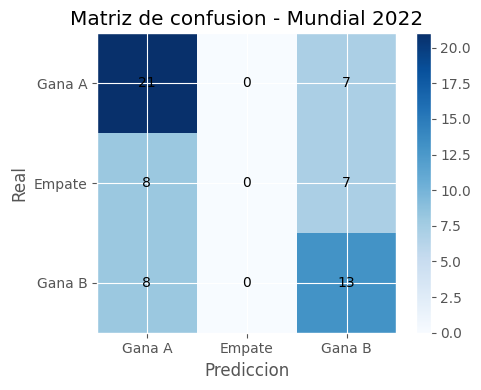

In [10]:
probs, goals = dashboard_model.predict(X_test_s, verbose=0)  # Predice con modelo del dashboard.
pred = probs.argmax(axis=1)  # Obtiene clase estimada.
print(classification_report(y_test, pred, target_names=["Gana A", "Empate", "Gana B"]))  # Reporte de test.
cm = confusion_matrix(y_test, pred)  # Calcula matriz.
fig, ax = plt.subplots(figsize=(5, 4))  # Crea figura.
image = ax.imshow(cm, cmap="Blues")  # Dibuja mapa de calor.
ax.set_xticks(range(3), ["Gana A", "Empate", "Gana B"])  # Etiquetas prediccion.
ax.set_yticks(range(3), ["Gana A", "Empate", "Gana B"])  # Etiquetas reales.
for i in range(3):  # Recorre filas.
    for j in range(3):  # Recorre columnas.
        ax.text(j, i, cm[i, j], ha="center", va="center")  # Escribe conteo.
ax.set_title("Matriz de confusion - Mundial 2022")  # Titulo.
ax.set_xlabel("Prediccion")  # Eje X.
ax.set_ylabel("Real")  # Eje Y.
fig.colorbar(image, ax=ax)  # Barra de color.
plt.tight_layout()  # Ajusta grafico.
plt.show()  # Muestra grafico.